## Setup

Set your student-ID seed here, then run the cells below to generate the graph, compute the exact maximum cut, and compare QAOA with simulated annealing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

print(f"Current working directory: {Path.cwd()}")

Current working directory: /Users/linweichen/Documents/Homework/Quantum_algorithm/Hw2/problem2


## 1. Graph generation and visualization

Generate the graph directly in this cell and plot it.

Seed: 11202038
Nodes: 8, Edges: 19
Edges: [(0, 2), (0, 3), (0, 5), (0, 6), (0, 7), (1, 4), (1, 5), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 7), (4, 5), (5, 6), (6, 7)]


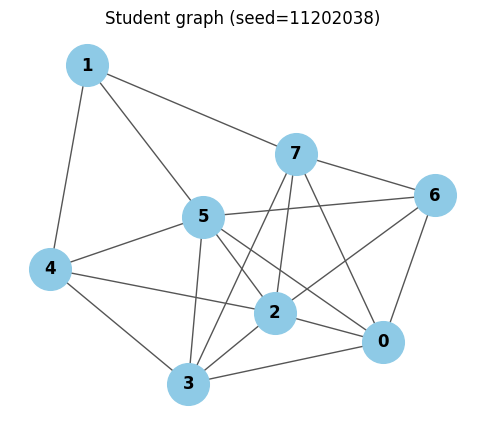

In [ ]:
import itertools
import math

seed = 11202038
G = nx.gnp_random_graph(n=8, p=0.5, seed=seed)


def edges(G):
    return sorted((min(u, v), max(u, v)) for u, v in G.edges())


def cut(G, b):
    return sum(1 for u, v in G.edges() if int(b[u]) != int(b[v]))


print(f"Seed: {seed}")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Edges: {edges(G)}")

plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=seed + 1)
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#555555",
    node_size=900,
    font_weight="bold",
)
plt.title(f"Student graph (seed={seed})")
plt.axis("off")
# plt.savefig('../report/figure/student_graph.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import itertools
import math

best = -math.inf
bits_best = []
parts_best = []

for b in itertools.product((0, 1), repeat=G.number_of_nodes()):
    c = cut(G, b)
    if c > best:
        best = c
        bits_best = [tuple(b)]
        parts_best = [tuple(i for i, x in enumerate(b) if x == 0)]
    elif c == best:
        bits_best.append(tuple(b))
        parts_best.append(tuple(i for i, x in enumerate(b) if x == 0))

print(f"Exact maximum cut value: {best}")
print(f"Number of optimal bitstrings: {len(bits_best)}")
print("Optimal partitions:")
for left, right in zip(parts_best, [tuple(i for i in range(G.number_of_nodes()) if i not in p) for p in parts_best]):
    print(f"  {left} | {right}")

Exact maximum cut value: 14
Number of optimal bitstrings: 2
Optimal partitions:
  (0, 4, 5, 7) | (1, 2, 3, 6)
  (1, 2, 3, 6) | (0, 4, 5, 7)


## QAOA Helpers

These functions are used by the p=1 landscape and QAOA optimization sections.

In [4]:
import dimod
import neal
import numpy as np
import pennylane as qml


def cost_h(g):
    c = []
    o = []
    for u, v in edges(g):
        c.append(0.5)
        o.append(qml.PauliZ(u) @ qml.PauliZ(v))
    s = -0.5 * g.number_of_edges()
    return qml.Hamiltonian(c, o), s


def cost_layer(gamma, g):
    for u, v in edges(g):
        qml.IsingZZ(gamma, wires=[u, v])


def mixer_layer(beta, n):
    for w in range(n):
        qml.RX(2.0 * beta, wires=w)


def expval(g, gs, bs):
    n = g.number_of_nodes()
    h, _ = cost_h(g)
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, interface="autograd")
    def circ(gammas, betas):
        for w in range(n):
            qml.Hadamard(wires=w)
        for i in range(len(gammas)):
            cost_layer(gammas[i], g)
            mixer_layer(betas[i], n)
        return qml.expval(h)

    return float(circ(np.asarray(gs, dtype=float), np.asarray(bs, dtype=float)))


def land(g, gp=50, bp=50):
    gs = np.linspace(0.0, 2.0 * np.pi, gp)
    bs = np.linspace(0.0, np.pi, bp)
    z = np.zeros((gp, bp), dtype=float)

    for i, gamma in enumerate(gs):
        for j, beta in enumerate(bs):
            z[i, j] = expval(g, [gamma], [beta])

    return gs, bs, z


def sample_qaoa(g, gs, bs):
    n = g.number_of_nodes()
    dev = qml.device("default.qubit", wires=n, shots=1000)

    @qml.qnode(dev, interface="autograd")
    def circ(gammas, betas):
        for w in range(n):
            qml.Hadamard(wires=w)
        for i in range(len(gammas)):
            for u, v in edges(g):
                qml.IsingZZ(gammas[i], wires=[u, v])
            for w in range(n):
                qml.RX(2.0 * betas[i], wires=w)
        return qml.sample(wires=range(n))

    s = circ(np.asarray(gs, dtype=float), np.asarray(bs, dtype=float))
    if s.ndim == 1:
        b = tuple(int(v) for v in s.tolist())
    else:
        cnt = {}
        for row in s:
            k = tuple(int(v) for v in row.tolist())
            cnt[k] = cnt.get(k, 0) + 1
        b = max(cnt.items(), key=lambda x: x[1])[0]

    return b, cut(g, b)


def opt_qaoa(g, p, seed, steps=120, lr=0.15):
    rng = np.random.default_rng(seed)
    gs = qml.numpy.array(rng.uniform(0.0, 2.0 * np.pi, size=p), requires_grad=True)
    bs = qml.numpy.array(rng.uniform(0.0, np.pi, size=p), requires_grad=True)

    dev = qml.device("default.qubit", wires=g.number_of_nodes())
    h, s = cost_h(g)

    @qml.qnode(dev, interface="autograd")
    def circ(gammas, betas):
        for w in range(g.number_of_nodes()):
            qml.Hadamard(wires=w)
        for i in range(p):
            cost_layer(gammas[i], g)
            mixer_layer(betas[i], g.number_of_nodes())
        return qml.expval(h)

    opt = qml.AdamOptimizer(stepsize=lr)
    best = (gs, bs)
    best_e = float(circ(gs, bs))

    for _ in range(steps):
        gs, bs = opt.step(circ, gs, bs)
        e = float(circ(gs, bs))
        if e < best_e:
            best_e = e
            best = (
                qml.numpy.array(gs, requires_grad=False),
                qml.numpy.array(bs, requires_grad=False),
            )

    b, c = sample_qaoa(g, best[0], best[1])
    return {
        "p": p,
        "gammas": np.asarray(best[0], dtype=float).tolist(),
        "betas": np.asarray(best[1], dtype=float).tolist(),
        "objective": best_e,
        "cut": c,
        "bitstring": b,
        "shift": s,
    }

## 3. p=1 QAOA energy landscape

Evaluate the 2D landscape on a grid and mark the minimum point.

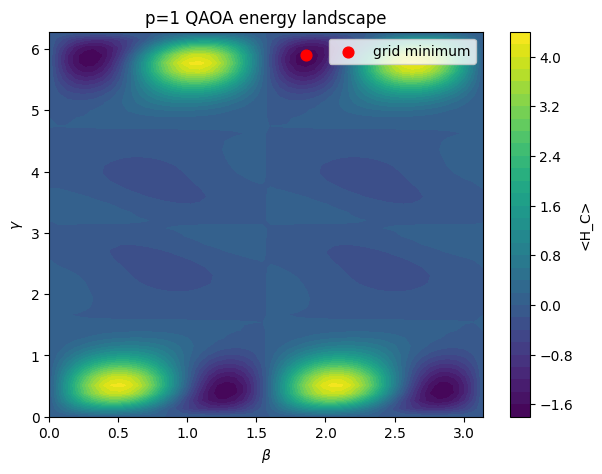

Landscape grid evaluated in 13.01s
Landscape minimum (grid): energy=-1.789547, gamma=5.898500, beta=1.859310


In [ ]:
import time

land_start = time.perf_counter()
gs, bs, z = land(G, gp=50, bp=50)
land_time = time.perf_counter() - land_start
min_i = np.unravel_index(np.argmin(z), z.shape)
best_g = gs[min_i[0]]
best_b = bs[min_i[1]]
best_e = z[min_i]

plt.figure(figsize=(7, 5))
plt.contourf(bs, gs, z, levels=30, cmap="viridis")
plt.colorbar(label="<H_C>")
plt.scatter([best_b], [best_g], color="red", s=60, label="grid minimum")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.title("p=1 QAOA energy landscape")
plt.legend()
# plt.savefig('../report/figure/energy_landscape_maxcut.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Landscape grid evaluated in {land_time:.2f}s")
print(f"Landscape minimum (grid): energy={best_e:.6f}, gamma={best_g:.6f}, beta={best_b:.6f}")

## 4. QAOA for p = 1 to 4

Optimize the variational parameters at depths 1 through 4 and record the best cut and parameters.

In [6]:
qaoa_results = []
for p in range(1, 5):
    start = time.perf_counter()
    result = opt_qaoa(G, p=p, seed=seed, steps=60, lr=0.12)
    elapsed = time.perf_counter() - start
    r = result["cut"] / best if best else 0.0
    qaoa_results.append(
        {
            "method": f"QAOA p={p}",
            "cut": result["cut"],
            "ratio": r,
            "time": elapsed,
            "gammas": result["gammas"],
            "betas": result["betas"],
            "bitstring": result["bitstring"],
        }
    )

for row in qaoa_results:
    print(row["method"], "cut=", row["cut"], "ratio=", f"{row['ratio']:.3f}", "time=", f"{row['time']:.2f}s")
    print("  gammas:", np.round(row["gammas"], 6).tolist())
    print("  betas :", np.round(row["betas"], 6).tolist())
    print("  bitstring:", row["bitstring"])

/Users/linweichen/Documents/Homework/Quantum_algorithm/Hw2/.venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


QAOA p=1 cut= 10 ratio= 0.714 time= 1.02s
  gammas: [3.927435]
  betas : [2.268794]
  bitstring: (0, 0, 1, 0, 1, 1, 1, 0)
QAOA p=2 cut= 10 ratio= 0.714 time= 1.61s
  gammas: [3.697055, 5.728299]
  betas : [0.446674, 2.266471]
  bitstring: (1, 1, 0, 1, 1, 0, 1, 1)
QAOA p=3 cut= 11 ratio= 0.786 time= 2.17s
  gammas: [3.654672, 4.957979, 1.997977]
  betas : [0.497114, -0.404263, 1.971571]
  bitstring: (1, 1, 0, 1, 0, 0, 0, 0)
QAOA p=4 cut= 14 ratio= 1.000 time= 2.69s
  gammas: [3.826998, 5.591699, 2.777147, 2.298054]
  betas : [0.120054, 1.838376, 1.868618, -0.0017]
  bitstring: (1, 0, 0, 0, 1, 1, 0, 1)


## Annealing Helpers

These functions are used by the simulated-annealing comparison section.

In [7]:
import time


def sample_sa(g, seed, num_reads=1000):
    linear = {node: 0.0 for node in g.nodes()}
    quadratic = {}
    for u, v in edges(g):
        linear[u] -= 1.0
        linear[v] -= 1.0
        quadratic[(u, v)] = quadratic.get((u, v), 0.0) + 2.0

    bqm = dimod.BinaryQuadraticModel(linear, quadratic, 0.0, dimod.BINARY)
    sampler = neal.SimulatedAnnealingSampler()

    start = time.perf_counter()
    sampleset = sampler.sample(bqm, num_reads=num_reads, seed=seed)
    elapsed = time.perf_counter() - start

    best = sampleset.first.sample
    b = tuple(int(best[node]) for node in range(g.number_of_nodes()))
    return {
        "bitstring": b,
        "cut": cut(g, b),
        "objective": float(sampleset.first.energy),
        "time": elapsed,
        "num_reads": num_reads,
    }


def ratio(found, optimal):
    if optimal == 0:
        return 1.0 if found == 0 else 0.0
    return float(found) / float(optimal)


print("Loaded annealing helpers.")

Loaded annealing helpers.


## 5. Simulated annealing and comparison

Run the annealer and print a compact comparison table across all methods.

In [8]:
sa_start = time.perf_counter()
sa_result = sample_sa(G, seed=seed, num_reads=1000)
sa_elapsed = time.perf_counter() - sa_start
sa_ratio = ratio(sa_result["cut"], best)

comparison_rows = [
    {
        "method": "Brute force",
        "cut": best,
        "ratio": 1.0,
        "time": 0.0,
    },
    {
        "method": "Simulated annealing",
        "cut": sa_result["cut"],
        "ratio": sa_ratio,
        "time": sa_result["time"],
    },
]
comparison_rows.extend(
    {
        "method": row["method"],
        "cut": row["cut"],
        "ratio": row["ratio"],
        "time": row["time"],
    }
    for row in qaoa_results
)

print("Comparison summary:")
for row in comparison_rows:
    print(f"{row['method']:<18} cut={row['cut']:>2} ratio={row['ratio']:.3f} time={row['time']:.3f}s")

print("\nSimulated annealing:")
print(sa_result)
print(f"SA wrapper time: {sa_elapsed:.2f}s")

Comparison summary:
Brute force        cut=14 ratio=1.000 time=0.000s
Simulated annealing cut=14 ratio=1.000 time=0.086s
QAOA p=1           cut=10 ratio=0.714 time=1.018s
QAOA p=2           cut=10 ratio=0.714 time=1.610s
QAOA p=3           cut=11 ratio=0.786 time=2.166s
QAOA p=4           cut=14 ratio=1.000 time=2.691s

Simulated annealing:
{'bitstring': (0, 1, 1, 1, 0, 0, 1, 0), 'cut': 14, 'objective': -14.0, 'time': 0.08610750001389533, 'num_reads': 1000}
SA wrapper time: 0.09s
